# Self-Serve Data Explorer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/self-serve-explorer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/self-serve-explorer/demo.ipynb)

> Analysts get pinged for every number. A self-serve explorer lets anyone pivot, aggregate, and filter — no SQL, no ticket.

Most "can you pull this number?" requests are one `GROUP BY` away from an answer. A self-serve
explorer turns that into a form: pick dimensions, a measure, an aggregation, some filters - and the
engine does what an analyst would have typed. This notebook builds that engine.

**What this notebook covers**
1. A query spec a business user can fill in (no SQL)
2. The engine: group-by, pivot, filter, top-N
3. Auto-detecting dimensions vs measures
4. Answering four real questions off one dataset
5. A result, visualized


## Step 1 - The no-SQL query spec

Everything a routine data pull needs, as fields: `rows` (group by), `measure` + `agg`, an optional
pivot `columns`, `filters`, and `top_n`. Fill it in, get a table.

In [1]:
from explorer import (run_query, ExploreQuery, profile_columns,
                      suggest_queries, sample_dataframe)

df = sample_dataframe()
print(df.head().to_string(index=False))
print(f"\n{len(df)} rows.")


region plan  channel  amount  seats   month
    US team referral   83.90     11 2026-04
    EU team referral    7.68     11 2026-06
    EU free referral   32.18      3 2026-06
    US team  organic  153.37     17 2026-05
    US free  organic   23.13     16 2026-04

400 rows.


## Step 2 - Auto-detect dimensions vs measures

Before a user can explore, the tool has to know what's sliceable (dimensions) vs summable
(measures). A quick profile does it, so the UI can offer the right column in the right dropdown.

In [2]:
prof = profile_columns(df)
print("Dimensions (group by):", prof["dimensions"])
print("Measures (aggregate) :", prof["measures"])


Dimensions (group by): ['region', 'plan', 'channel', 'month']
Measures (aggregate) : ['amount', 'seats']


## Step 3 - Answer real questions

Four questions that would each have been a Slack ping to an analyst - answered by filling in the
spec instead.

In [3]:
print("Q: Total revenue by region (top 4)")
print(run_query(df, ExploreQuery(rows=["region"], measure="amount", agg="sum", top_n=4)).to_string(index=False))

print("\nQ: Average deal size, region x plan")
print(run_query(df, ExploreQuery(rows=["region"], measure="amount", agg="mean", columns="plan")).round(0).to_string(index=False))

print("\nQ: Revenue by channel, US + EU only")
print(run_query(df, ExploreQuery(rows=["channel"], measure="amount", agg="sum",
                                 filters={"region": ["US", "EU"]})).to_string(index=False))


Q: Total revenue by region (top 4)
region  sum_amount
    US    15007.51
    EU     8311.46
  APAC     6738.47
 LATAM     2719.96

Q: Average deal size, region x plan
region  enterprise  free  pro  team
  APAC       104.0  80.0 69.0  97.0
    EU        77.0  68.0 74.0  74.0
 LATAM        75.0 118.0 77.0  53.0
    US        82.0  77.0 86.0  93.0

Q: Revenue by channel, US + EU only
 channel  sum_amount
    paid     8647.12
 organic     8251.34
referral     6420.51


## Step 4 - Starter questions for a blank page

New users freeze at an empty explorer. A couple of auto-suggested queries give them a running
start - and teach the tool's shape by example.

In [4]:
for q in suggest_queries(df):
    piv = f" x {q.columns}" if q.columns else ""
    print(f"- {q.agg}({q.measure}) by {q.rows}{piv}")


- sum(amount) by ['region']
- mean(amount) by ['region'] x plan
- count(region) by ['region']


## Step 5 - Visualize a result

The explorer returns a tidy frame, so charting is a one-liner. Here: revenue by region, the single
most-asked slice.

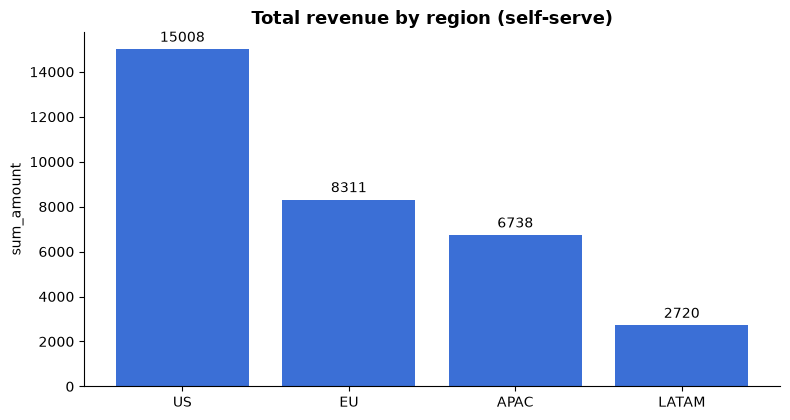

In [5]:
import matplotlib.pyplot as plt

res = run_query(df, ExploreQuery(rows=["region"], measure="amount", agg="sum"))
fig, ax = plt.subplots(figsize=(8, 4.3))
bars = ax.bar(res["region"], res["sum_amount"], color="#3b6fd6")
ax.set_title("Total revenue by region (self-serve)", fontsize=13, weight="bold")
ax.set_ylabel("sum_amount")
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("explore_result.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| User picks | Engine does |
|-----------|-------------|
| rows (dimensions) | `GROUP BY` |
| measure + agg | the aggregation |
| columns | a pivot |
| filters | `WHERE ... IN (...)` |
| top_n | rank + head |

The explorer doesn't make analysts obsolete - it frees them from the *routine* pulls so they can do
the hard analysis. Every question answered here is one that never became a ticket.

**Extend it:** back the engine with your warehouse via a metrics layer (Day 101) so self-serve
numbers match governed definitions, and add saved views so common questions become one click.

In [6]:
# --- Try your own exploration ---
# q = ExploreQuery(rows=["plan"], measure="seats", agg="mean", filters={"channel": ["paid"]})
# print(run_query(df, q))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 105,
Month 11: Analytics Engineering & BI.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`